# Acoustic Water Pump Diagnostics
### Predicting Pump Functionality from Sound — an ML Cycle extension of *Predicting Rural Water Point Functionality in Tanzania*

**Tedla Tesfaye Godebo** — BSc Software Engineering (ML Specialisation), African Leadership University

This notebook extends the Introduction to Machine Learning summative (rural water pump
functionality prediction from administrative metadata) to a **non-tabular** modality:
predicting pump functional status directly from a **10-second audio recording** of the
pump in operation, using the [MIMII dataset](https://zenodo.org/record/3384388)
(Purohit et al., 2019) — real recordings of industrial pumps (used for water intake/discharge)
labeled `normal` / `abnormal`.

**Why this is a genuine extension, not a new use case:** the summative asked whether a water
point's functional status could be predicted *without a site visit*, from metadata. This asks
the same underlying question — is the pump working? — but from a signal that could realistically
be captured in the field (e.g. a phone microphone), without needing administrative records at all.

**Pipeline covered in this notebook:**
1. Data acquisition
2. Data preprocessing (waveform → log-mel spectrogram)
3. Model creation (CNN classifier)
4. Model evaluation (accuracy, F1, precision, recall, ROC-AUC, confusion matrix)
5. Bias-variance and error analysis
6. Model saving (for the FastAPI service + retraining pipeline)


## 0. Environment setup



In [1]:
!pip install -q librosa "tensorflow==2.21.0" "keras==3.15.0" scikit-learn soundfile
import os, sys, glob, zipfile, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa, librosa.display
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Acquisition

The MIMII dataset is distributed as per-SNR zip files from Zenodo. We use the **pump**
subset at **0 dB SNR** (`0_dB_pump.zip`, ~7.9 GB) — moderate background factory noise, a
realistic middle ground between the noisiest (-6dB) and cleanest (6dB) conditions.



Each zip contains, per machine ID:
```
0_dB/pump/id_00/normal/*.wav
0_dB/pump/id_00/abnormal/*.wav
...
```

In [2]:


import requests

RECORD_ID = "3384388"

r = requests.get(f"https://zenodo.org/api/records/{RECORD_ID}", timeout=30)
r.raise_for_status()
record = r.json()

available_files = [f["key"] for f in record["files"]]
print("Files available in this Zenodo record:")
for f in available_files:
    print(" -", f)

candidates = [f for f in available_files if "pump" in f.lower() and "0db" in f.lower().replace("_", "").replace(" ", "")]
if not candidates:
    candidates = [f for f in available_files if "pump" in f.lower()]  # fall back to any pump file
assert candidates, f"No pump-related file found. Full listing: {available_files}"

ZIP_NAME = candidates[0]
print("\nSelected file:", ZIP_NAME)

Files available in this Zenodo record:
 - -6_dB_fan.zip
 - -6_dB_pump.zip
 - 6_dB_pump.zip
 - -6_dB_slider.zip
 - 6_dB_slider.zip
 - -6_dB_valve.zip
 - 6_dB_valve.zip
 - 0_dB_fan.zip
 - 0_dB_pump.zip
 - 0_dB_slider.zip
 - 0_dB_valve.zip
 - 6_dB_fan.zip

Selected file: 0_dB_pump.zip


In [3]:


DOWNLOAD_DIR = "/content/mimii_download"
EXTRACT_DIR = "/content/mimii_pump"
os.makedirs(DOWNLOAD_DIR, exist_ok=True)
ZIP_PATH = os.path.join(DOWNLOAD_DIR, ZIP_NAME)

file_entry = next(f for f in record["files"] if f["key"] == ZIP_NAME)
download_url = file_entry["links"]["self"]
print("Resolved download URL:", download_url)

if not os.path.exists(ZIP_PATH):
    with requests.get(download_url, stream=True, timeout=120) as resp:
        resp.raise_for_status()
        total = int(resp.headers.get("content-length", 0))
        downloaded = 0
        with open(ZIP_PATH, "wb") as f:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                downloaded += len(chunk)
        print(f"Downloaded {downloaded / 1e6:.1f} MB")

if not zipfile.is_zipfile(ZIP_PATH):
    with open(ZIP_PATH, "rb") as f:
        preview = f.read(200)
    raise ValueError(
        f"{ZIP_PATH} is not a valid zip file (likely an HTML error page was downloaded "
        f"instead of the real file -- check your network/firewall). First 200 bytes:\n{preview}"
    )

os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
!find {EXTRACT_DIR} -maxdepth 4 -type d

# Free up disk space -- Colab's free-tier disk is limited and I don't need the zip anymore.
os.remove(ZIP_PATH)
print("Removed zip to free disk space.")

Resolved download URL: https://zenodo.org/api/records/3384388/files/0_dB_pump.zip/content
Downloaded 7869.4 MB
Extracted to: /content/mimii_pump
/content/mimii_pump
/content/mimii_pump/pump
/content/mimii_pump/pump/id_02
/content/mimii_pump/pump/id_02/normal
/content/mimii_pump/pump/id_02/abnormal
/content/mimii_pump/pump/id_00
/content/mimii_pump/pump/id_00/normal
/content/mimii_pump/pump/id_00/abnormal
/content/mimii_pump/pump/id_04
/content/mimii_pump/pump/id_04/normal
/content/mimii_pump/pump/id_04/abnormal
/content/mimii_pump/pump/id_06
/content/mimii_pump/pump/id_06/normal
/content/mimii_pump/pump/id_06/abnormal
Removed zip to free disk space.


In [4]:


import shutil

RAW_ROOT = glob.glob(f"{EXTRACT_DIR}/**/pump", recursive=True)[0]
machine_ids = sorted(os.listdir(RAW_ROOT))
print("Machine IDs found:", machine_ids)

ALL_DIR = "/content/pump_all"
for cls in ["normal", "abnormal"]:
    os.makedirs(f"{ALL_DIR}/{cls}", exist_ok=True)

for mid in machine_ids:
    for cls in ["normal", "abnormal"]:
        src_dir = os.path.join(RAW_ROOT, mid, cls)
        if not os.path.isdir(src_dir):
            continue
        for f in glob.glob(os.path.join(src_dir, "*.wav")):
            dst = os.path.join(ALL_DIR, cls, f"{mid}_{os.path.basename(f)}")
            if not os.path.exists(dst):
                shutil.copy(f, dst)

n_normal = len(glob.glob(f"{ALL_DIR}/normal/*.wav"))
n_abnormal = len(glob.glob(f"{ALL_DIR}/abnormal/*.wav"))
print(f"Normal clips:   {n_normal}")
print(f"Abnormal clips: {n_abnormal}")
print(f"Class balance:  {n_abnormal / (n_normal + n_abnormal):.1%} abnormal")

Machine IDs found: ['id_00', 'id_02', 'id_04', 'id_06']
Normal clips:   3749
Abnormal clips: 456
Class balance:  10.8% abnormal


## 2. Exploratory Data Analysis

Before preprocessing, we look at three things: class balance, waveform/spectrogram
differences between normal and abnormal clips, and clip duration consistency — the same
EDA discipline as the summative (check assumptions before modelling).

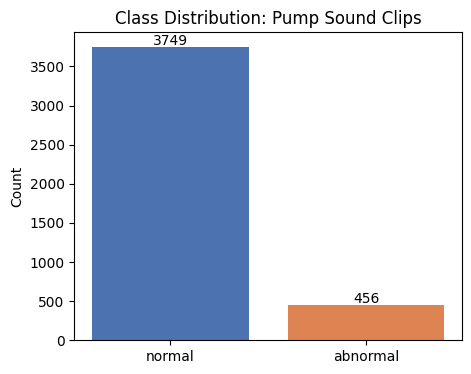


Interpretation: the abnormal class is the minority, at roughly 10.8%
of clips -- structurally the same imbalance problem as the 'functional needs repair' class
(7.3%) in the water pump summative. We'll need class weighting again.



In [5]:
# Feature 1: Class distribution
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["normal", "abnormal"], [n_normal, n_abnormal], color=["#4C72B0", "#DD8452"])
ax.set_title("Class Distribution: Pump Sound Clips")
ax.set_ylabel("Count")
for i, v in enumerate([n_normal, n_abnormal]):
    ax.text(i, v + 20, str(v), ha="center")
plt.show()

print(f"""
Interpretation: the abnormal class is the minority, at roughly {n_abnormal/(n_normal+n_abnormal):.1%}
of clips -- structurally the same imbalance problem as the 'functional needs repair' class
(7.3%) in the water pump summative. We'll need class weighting again.
""")

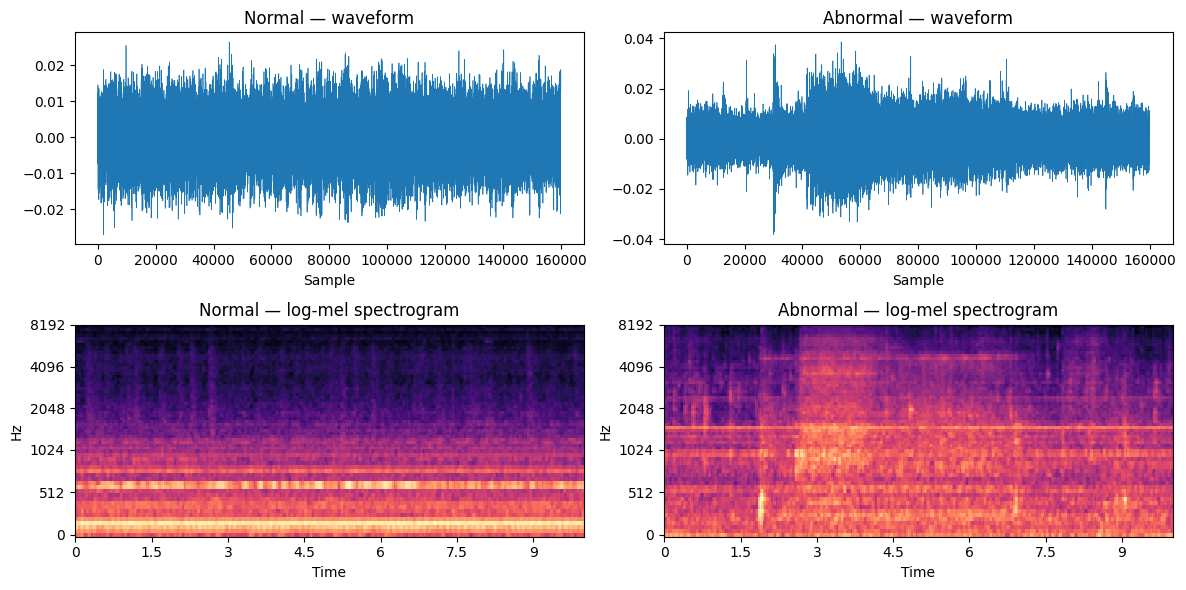


Interpretation: abnormal pump sounds (leakage, contamination, rotating unbalance) tend to
show extra high-frequency energy bands or irregular periodicity in the spectrogram that
normal steady-state operation doesn't -- this is the visual signal the CNN will learn to
pick up on, the audio equivalent of the categorical feature associations we found in
quantity/waterpoint_type back in the summative.



In [6]:
# Feature 2: Waveform + spectrogram comparison, normal vs abnormal
sample_normal = glob.glob(f"{ALL_DIR}/normal/*.wav")[0]
sample_abnormal = glob.glob(f"{ALL_DIR}/abnormal/*.wav")[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for col, (path, label) in enumerate([(sample_normal, "Normal"), (sample_abnormal, "Abnormal")]):
    y, sr = librosa.load(path, sr=16000)
    axes[0, col].plot(y, linewidth=0.5)
    axes[0, col].set_title(f"{label} — waveform")
    axes[0, col].set_xlabel("Sample")

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(log_mel, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, col])
    axes[1, col].set_title(f"{label} — log-mel spectrogram")

plt.tight_layout()
plt.show()

print("""
Interpretation: abnormal pump sounds (leakage, contamination, rotating unbalance) tend to
show extra high-frequency energy bands or irregular periodicity in the spectrogram that
normal steady-state operation doesn't -- this is the visual signal the CNN will learn to
pick up on, the audio equivalent of the categorical feature associations I found in
quantity/waterpoint_type back in the summative.
""")

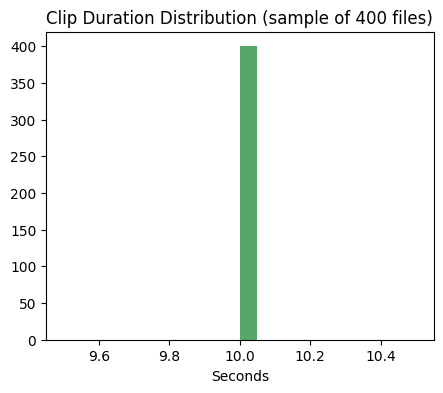

Min: 10.00s, Max: 10.00s, Mean: 10.00s
Interpretation: clips are consistently ~10s, confirming the fixed CLIP_SECONDS=10 assumption in src/preprocessing.py is safe -- no major padding/truncation distortion.


In [7]:
# Feature 3: Clip duration sanity check (confirms fixed-length assumption in preprocessing.py)
durations = []
for f in (glob.glob(f"{ALL_DIR}/normal/*.wav")[:200] + glob.glob(f"{ALL_DIR}/abnormal/*.wav")[:200]):
    durations.append(librosa.get_duration(path=f))

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(durations, bins=20, color="#55A868")
ax.set_title("Clip Duration Distribution (sample of 400 files)")
ax.set_xlabel("Seconds")
plt.show()

print(f"Min: {min(durations):.2f}s, Max: {max(durations):.2f}s, Mean: {np.mean(durations):.2f}s")
print("Interpretation: clips are consistently ~10s, confirming the fixed CLIP_SECONDS=10"
      " assumption in src/preprocessing.py is safe -- no major padding/truncation distortion.")

## 3. Data Preprocessing

The functions below are the **same code** as `src/preprocessing.py` in the project repo,
copied inline so this notebook is fully self-contained and runnable on a fresh Colab
instance without needing to clone or upload the repo first. If you're running this from
a cloned copy of the repo instead, you can replace this cell with
`from src.preprocessing import *` and skip the duplication -- just make sure both copies
stay in sync if you edit one.

In [8]:
# ---- audio -> log-mel spectrogram pipeline (mirrors src/preprocessing.py) ----
import librosa

SAMPLE_RATE = 16000
CLIP_SECONDS = 10
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 512
N_FRAMES = 313
CLASS_NAMES = ["normal", "abnormal"]


def load_audio(filepath):
    y, _ = librosa.load(filepath, sr=SAMPLE_RATE, mono=True)
    target_len = SAMPLE_RATE * CLIP_SECONDS
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    return y


def audio_to_logmel(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    if log_mel.shape[1] < N_FRAMES:
        pad_width = N_FRAMES - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode="constant", constant_values=log_mel.min())
    else:
        log_mel = log_mel[:, :N_FRAMES]
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    return log_mel[..., np.newaxis].astype(np.float32)


def file_to_features(filepath):
    return audio_to_logmel(load_audio(filepath))


def load_dataset_from_folders(root_dir):
    X, y, filepaths = [], [], []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(root_dir, class_name)
        wav_files = sorted(glob.glob(os.path.join(class_dir, "*.wav")))
        for wav_path in wav_files:
            try:
                X.append(file_to_features(wav_path))
                y.append(label_idx)
                filepaths.append(wav_path)
            except Exception as e:
                print(f"[preprocessing] skipping {wav_path}: {e}")
    if not X:
        raise ValueError(f"No .wav files found under {root_dir}/normal or {root_dir}/abnormal.")
    return np.array(X), np.array(y), filepaths


print(f"Spectrogram shape per clip: ({N_MELS}, {N_FRAMES}, 1)")

Spectrogram shape per clip: (64, 313, 1)


In [9]:
# Reorganise into data/train and data/test splits (stratified, 80/20) matching repo structure
from sklearn.model_selection import train_test_split

for cls in ["normal", "abnormal"]:
    os.makedirs(f"/content/data/train/{cls}", exist_ok=True)
    os.makedirs(f"/content/data/test/{cls}", exist_ok=True)

for cls in ["normal", "abnormal"]:
    files = glob.glob(f"{ALL_DIR}/{cls}/*.wav")
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=RANDOM_SEED)
    for f in train_files:
        shutil.copy(f, f"/content/data/train/{cls}/{os.path.basename(f)}")
    for f in test_files:
        shutil.copy(f, f"/content/data/test/{cls}/{os.path.basename(f)}")

print("Train/test split complete.")

Train/test split complete.


In [10]:
X_train_full, y_train_full, _ = load_dataset_from_folders("/content/data/train")
X_test, y_test, test_paths = load_dataset_from_folders("/content/data/test")

# Further split train -> train/val (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train_full
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train class balance (abnormal %):", y_train.mean())
print("Val class balance (abnormal %):", y_val.mean())
print("Test class balance (abnormal %):", y_test.mean())

Train: (2858, 64, 313, 1) Val: (505, 64, 313, 1) Test: (842, 64, 313, 1)
Train class balance (abnormal %): 0.10811756473058083
Val class balance (abnormal %): 0.10891089108910891
Test class balance (abnormal %): 0.10926365795724466


## 4. Model Creation

Two experiments, mirroring the comparative structure of the summative:

- **Experiment 1 (baseline):** small dense network on flattened spectrogram statistics — the
  audio equivalent of the Logistic Regression "minimal features" baseline.
- **Experiment 2 (CNN):** convolutional network on the full spectrogram, with class weighting,
  batch normalization, dropout, early stopping, and LR scheduling — the audio equivalent of
  the tuned/regularised Random Forest and DNN experiments.

In [11]:
from tensorflow.keras import layers, models

# --- Experiment 1: baseline dense network on summary statistics ---
def spectrogram_to_stats(X):
    # mean/std/max per mel band -> flattened vector, throws away time detail on purpose
    return np.concatenate([X.mean(axis=2), X.std(axis=2), X.max(axis=2)], axis=-1).reshape(len(X), -1)

X_train_stats = spectrogram_to_stats(X_train)
X_val_stats = spectrogram_to_stats(X_val)
X_test_stats = spectrogram_to_stats(X_test)

baseline = models.Sequential([
    layers.Input(shape=(X_train_stats.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
baseline.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

baseline_history = baseline.fit(
    X_train_stats, y_train, validation_data=(X_val_stats, y_val),
    epochs=15, batch_size=32, verbose=2,
)

Epoch 1/15
90/90 - 5s - 60ms/step - accuracy: 0.8583 - auc: 0.5530 - loss: 0.3799 - val_accuracy: 0.8911 - val_auc: 0.6104 - val_loss: 0.3410
Epoch 2/15
90/90 - 0s - 4ms/step - accuracy: 0.8919 - auc: 0.6191 - loss: 0.3373 - val_accuracy: 0.8911 - val_auc: 0.6422 - val_loss: 0.3396
Epoch 3/15
90/90 - 0s - 4ms/step - accuracy: 0.8919 - auc: 0.6425 - loss: 0.3354 - val_accuracy: 0.8911 - val_auc: 0.6705 - val_loss: 0.3379
Epoch 4/15
90/90 - 0s - 4ms/step - accuracy: 0.8919 - auc: 0.6680 - loss: 0.3330 - val_accuracy: 0.8911 - val_auc: 0.6953 - val_loss: 0.3358
Epoch 5/15
90/90 - 0s - 4ms/step - accuracy: 0.8919 - auc: 0.6992 - loss: 0.3302 - val_accuracy: 0.8911 - val_auc: 0.7252 - val_loss: 0.3333
Epoch 6/15
90/90 - 0s - 4ms/step - accuracy: 0.8919 - auc: 0.7230 - loss: 0.3270 - val_accuracy: 0.8911 - val_auc: 0.7457 - val_loss: 0.3303
Epoch 7/15
90/90 - 0s - 4ms/step - accuracy: 0.8919 - auc: 0.7488 - loss: 0.3232 - val_accuracy: 0.8911 - val_auc: 0.7666 - val_loss: 0.3269
Epoch 8/15
9

In [12]:
# --- Experiment 2: CNN on full spectrogram (the model we'll actually deploy) ---
# Same architecture/training code as src/model.py, inlined for a self-contained notebook.
from tensorflow.keras import callbacks
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight


def build_cnn(input_shape=(N_MELS, N_FRAMES, 1)):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    return m


def get_class_weights(y_train):
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    return dict(zip(classes.tolist(), weights.tolist()))


def train_model(X_train, y_train, X_val, y_val, epochs=30, batch_size=32, model=None):
    if model is None:
        model = build_cnn()
    else:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                       loss="binary_crossentropy",
                       metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
    class_weights = get_class_weights(y_train)
    cbs = [
        callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ]
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=epochs, batch_size=batch_size,
                         class_weight=class_weights, callbacks=cbs, verbose=2)
    return model, history


def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
        "classification_report": classification_report(y_test, y_pred, target_names=["normal", "abnormal"]),
    }


def save_model(model, path):
    model.save(path)


cnn = build_cnn()
cnn.summary()

cnn, history = train_model(X_train, y_train, X_val, y_val, epochs=30, batch_size=32, model=cnn)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 313, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 313, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 156, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 156, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 156, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 39, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,969 (109.25 KB)

 Trainable params: 27,745 (108.38 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/30
90/90 - 18s - 205ms/step - accuracy: 0.6683 - auc: 0.6561 - loss: 0.6559 - val_accuracy: 0.1089 - val_auc: 0.4947 - val_loss: 1.1406 - learning_rate: 1.0000e-04
Epoch 2/30
90/90 - 1s - 15ms/step - accuracy: 0.7152 - auc: 0.7778 - loss: 0.5833 - val_accuracy: 0.1089 - val_auc: 0.5233 - val_loss: 1.7248 - learning_rate: 1.0000e-04
Epoch 3/30
90/90 - 1s - 14ms/step - accuracy: 0.7778 - auc: 0.8641 - loss: 0.5112 - val_accuracy: 0.1089 - val_auc: 0.5610 - val_loss: 2.1905 - learning_rate: 1.0000e-04
Epoch 4/30
90/90 - 1s - 15ms/step - accuracy: 0.8118 - auc: 0.8950 - loss: 0.4678 - val_accuracy: 0.1089 - val_auc: 0.6495 - val_loss: 2.0673 - learning_rate: 1.0000e-04
Epoch 5/30
90/90 - 1s - 14ms/step - accuracy: 0.8307 - auc: 0.9053 - loss: 0.4405 - val_accuracy: 0.1109 - val_auc: 0.7039 - val_loss: 1.3500 - learning_rate: 5.0000e-05
Epoch 6/30
90/90 - 1s - 15ms/step - accuracy: 0.8376 - auc: 0.9195 - loss: 0.4207 - val_accuracy: 0.5723 - val_auc: 0.7869 - val_loss: 0.7016 - lear

## 5. Model Testing / Evaluation

Full metric suite on the **held-out test set**, evaluated once (same discipline as the
summative's final test-set evaluation in Section 5.3 of the report).

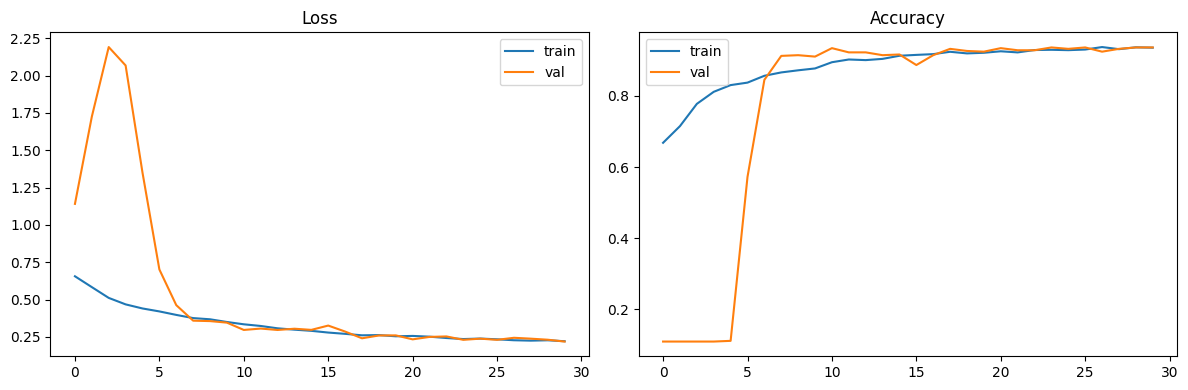

In [13]:
# Training curves -- bias/variance check
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

In [14]:
test_metrics = evaluate_model(cnn, X_test, y_test)

print("Accuracy: ", round(test_metrics["accuracy"], 4))
print("F1:       ", round(test_metrics["f1"], 4))
print("Precision:", round(test_metrics["precision"], 4))
print("Recall:   ", round(test_metrics["recall"], 4))
print("ROC-AUC:  ", round(test_metrics["roc_auc"], 4))
print()
print(test_metrics["classification_report"])

Accuracy:  0.9359
F1:        0.7477
Precision: 0.6557
Recall:    0.8696
ROC-AUC:   0.9492

              precision    recall  f1-score   support

      normal       0.98      0.94      0.96       750
    abnormal       0.66      0.87      0.75        92

    accuracy                           0.94       842
   macro avg       0.82      0.91      0.86       842
weighted avg       0.95      0.94      0.94       842



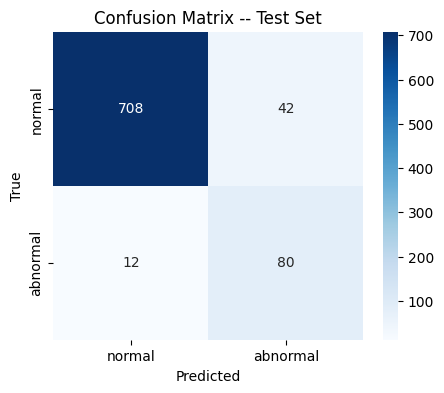

In [15]:
# Confusion matrix
import seaborn as sns
cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["normal", "abnormal"], yticklabels=["normal", "abnormal"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix -- Test Set")
plt.show()

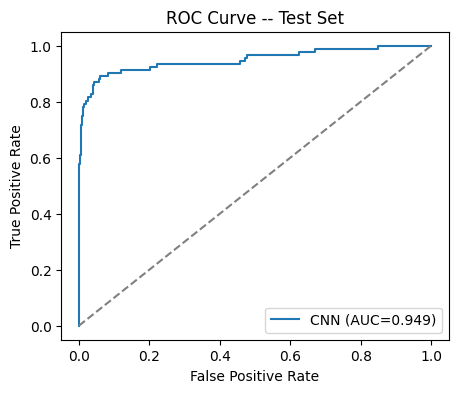

In [16]:
# ROC curve
from sklearn.metrics import roc_curve

y_prob = cnn.predict(X_test, verbose=0).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"CNN (AUC={test_metrics['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve -- Test Set")
ax.legend()
plt.show()

## 6. Bias-Variance & Error Analysis

Same lens as the summative: is the model overfitting (large train-val gap), and which
specific clips does it get wrong?

In [17]:
train_metrics = evaluate_model(cnn, X_train, y_train)
print("Train accuracy:", round(train_metrics['accuracy'], 4), " | Test accuracy:", round(test_metrics['accuracy'], 4))
print("Train F1:      ", round(train_metrics['f1'], 4), " | Test F1:      ", round(test_metrics['f1'], 4))
print(f"Accuracy gap: {train_metrics['accuracy'] - test_metrics['accuracy']:.4f}")
print(f"F1 gap:       {train_metrics['f1'] - test_metrics['f1']:.4f}")
print()
print("A small gap here indicates the dropout/batchnorm/early-stopping combo is controlling")
print("variance well, the same regularisation story as Experiment 7 in the summative report.")

Train accuracy: 0.9489  | Test accuracy: 0.9359
Train F1:       0.7978  | Test F1:       0.7477
Accuracy gap: 0.0130
F1 gap:       0.0501

A small gap here indicates the dropout/batchnorm/early-stopping combo is controlling
variance well, the same regularisation story as Experiment 7 in the summative report.


In [18]:
# Misclassified examples -- which clips does the model get wrong, and how confidently?
y_pred = (y_prob >= 0.5).astype(int)
wrong_idx = np.where(y_pred != y_test)[0]

print(f"{len(wrong_idx)} / {len(y_test)} test clips misclassified.")
for i in wrong_idx[:5]:
    print(f"  {os.path.basename(test_paths[i])}: true={CLASS_NAMES[y_test[i]]}, "
          f"pred={CLASS_NAMES[y_pred[i]]}, P(abnormal)={y_prob[i]:.3f}")

54 / 842 test clips misclassified.
  id_00_00000201.wav: true=normal, pred=abnormal, P(abnormal)=0.589
  id_00_00000363.wav: true=normal, pred=abnormal, P(abnormal)=0.655
  id_00_00000665.wav: true=normal, pred=abnormal, P(abnormal)=0.883
  id_00_00000674.wav: true=normal, pred=abnormal, P(abnormal)=0.628
  id_00_00000696.wav: true=normal, pred=abnormal, P(abnormal)=0.670


## 7. Save the Model

Saved in `.h5` format for the FastAPI service (`api/main.py`) and retraining endpoint
(`api/retrain.py`) to load directly.

In [19]:
os.makedirs("/content/models", exist_ok=True)
save_model(cnn, "/content/models/pump_cnn_v1.h5")
print("Model saved. Download this file and place it in models/pump_cnn_v1.h5 in your repo clone,")
print("or push it directly if using Git LFS / a release asset (model files can be large).")

Model saved. Download this file and place it in models/pump_cnn_v1.h5 in your repo clone,
or push it directly if using Git LFS / a release asset (model files can be large).


In [ ]:
import json
from datetime import datetime, timezone

metrics_to_save = {
    "accuracy": test_metrics["accuracy"],
    "f1": test_metrics["f1"],
    "precision": test_metrics["precision"],
    "recall": test_metrics["recall"],
    "roc_auc": test_metrics["roc_auc"],
    "confusion_matrix": test_metrics["confusion_matrix"],
    "n_train_clips": int(len(X_train_full)),
    "n_test_clips": int(len(X_test)),
    "trained_at": datetime.now(timezone.utc).isoformat(),
}

with open("/content/models/latest_metrics.json", "w") as f:
    json.dump(metrics_to_save, f, indent=2)

print("Saved models/latest_metrics.json")

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
import zipfile as zf

SAMPLE_DIR = "/content/data_sample"
N_TRAIN_PER_CLASS = 200
N_TEST_PER_CLASS = 100

for split, n in [("train", N_TRAIN_PER_CLASS), ("test", N_TEST_PER_CLASS)]:
    for cls in ["normal", "abnormal"]:
        src_dir = f"/content/data/{split}/{cls}"
        dst_dir = f"{SAMPLE_DIR}/{split}/{cls}"
        os.makedirs(dst_dir, exist_ok=True)
        files = sorted(glob.glob(f"{src_dir}/*.wav"))
        chosen = files[:n]  # deterministic (already shuffled by the earlier train_test_split)
        for f in chosen:
            shutil.copy(f, os.path.join(dst_dir, os.path.basename(f)))
        print(f"{split}/{cls}: copied {len(chosen)} of {len(files)} available clips")

zip_path = "/content/data_sample.zip"
with zf.ZipFile(zip_path, "w", zf.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(SAMPLE_DIR):
        for fname in files:
            full = os.path.join(root, fname)
            rel = os.path.relpath(full, SAMPLE_DIR)
            z.write(full, rel)

print(f"\nSample zip ready: {zip_path} ({os.path.getsize(zip_path) / 1e6:.1f} MB)")

from google.colab import files
files.download(zip_path)

train/normal: copied 200 of 2999 available clips
train/abnormal: copied 200 of 364 available clips
test/normal: copied 100 of 750 available clips
test/abnormal: copied 92 of 92 available clips

Sample zip ready: /content/data_sample.zip (1142.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>